# 03_modeling — モデルの学習

前処理済みデータを使って機械学習モデルを学習します。
このノートブックでは **モデル学習の理論と実装** をセットで学びます。

## モデル学習の 3 ステップ

1. **データ分割**: 学習用 (train) と検証用 (test) に分ける
2. **モデル選択**: タスクに適したアルゴリズムを選ぶ
3. **学習**: `model.fit(X_train, y_train)` で学習させる

## 機械学習タスクの種類

| タスク | 目的 | 例 |
|-|-|-|
| **回帰** | 連続値を予測 | 住宅価格, 売上, 気温 |
| **分類** | カテゴリを予測 | スパム判定, 病気の有無, 画像認識 |
| **クラスタリング** | 似たデータでグループ化 | 顧客セグメンテーション |
| **次元削減** | 特徴量を圧縮 | 可視化, ノイズ除去 |

今回は住宅価格を予測したいので **回帰** タスクです。


In [1]:
# ===== プロジェクトの src/ を import できるようにする共通の準備 =====
# notebooks/ から見て1つ上の階層がプロジェクトルート (= data_analysis_project)
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /Users/kenta.hoji.ea/Desktop/pythonデータ分析/data_analysis_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from src import data_loader, features, modeling, evaluation

%matplotlib inline
sns.set_theme(style='whitegrid')


## データの読み込みと準備

In [3]:
df = data_loader.load_processed('california_housing_fe')
print('shape:', df.shape)
df.head()


shape: (20640, 12)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price,Household,AllRooms,AllBedrms
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,126.0,880.0,129.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,1138.0,7099.0,1106.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,177.0,1467.0,190.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,219.0,1274.0,235.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,259.0,1627.0,280.0


In [4]:
# 説明変数 X と目的変数 y に分割
X, y = features.split_features_target(df, target_col='Price')
print('X shape:', X.shape)
print('y shape:', y.shape)


X shape: (20640, 11)
y shape: (20640,)


## 1. データ分割

データを **学習用** と **検証用** に分けるのは、

> 「**学習に使ったデータで評価しても本当の性能は測れない**」

ためです。学習に使っていない「未知のデータ」でこそ、モデルの汎化性能 (新しいデータへの対応力) を評価できます。

### 代表的な分割手法

| 手法 | 概要 | 使いどころ |
|-|-|-|
| **ホールドアウト法** | 1 回だけ train/test に分ける (例: 80%/20%) | 大規模データ, 手軽に検証したい |
| **k 分割交差検証** (k-fold CV) | k 個に分け、学習/評価を k 回繰り返して平均 | データが少ない, 信頼性のある評価がほしい |
| **層化 k 分割交差検証** (stratified k-fold) | クラス比率を保ったまま分割 | 不均衡なクラス分類 |


### ホールドアウト法

scikit-learn の `train_test_split` を使います。
- `test_size`: 検証用の割合 (慣例的に 0.2 〜 0.3)
- `random_state`: 乱数シード (固定すると再現可能)
- `stratify`: 分類タスクで層化抽出したい場合に y を渡す


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2,
)
print('train:', X_train.shape, y_train.shape)
print('test :', X_test.shape, y_test.shape)


train: (16512, 11) (16512,)
test : (4128, 11) (4128,)


### k 分割交差検証 (参考)

データが少ないときや、より信頼性のある評価がほしいときに使います。


In [6]:
# 5 分割 CV の例 (今回は実演のため小さなサブセットで)
small_X = X_train.iloc[:2000]
small_y = y_train.iloc[:2000]

kfold = KFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(
    LinearRegression(), small_X, small_y,
    cv=kfold, scoring='r2',
)
print(f'各 fold の R²: {scores.round(4)}')
print(f'平均 R²: {scores.mean():.4f} ± {scores.std():.4f}')


各 fold の R²: [0.62   0.7006 0.6149 0.6179 0.6826]
平均 R²: 0.6472 ± 0.0368


## 2. モデル選択

### モデル選びの考え方

1. **タスクのタイプを決める** (回帰? 分類? クラスタリング?)
2. **データの大きさ・特性を考慮**
3. **シンプルなモデルから試す** (まず線形回帰 → 木系 → アンサンブル)
4. **複数モデルを比較** して一番性能の良いものを選ぶ

scikit-learn 公式のチートシートも参考になります:
<https://scikit-learn.org/stable/tutorial/machine_learning_map/>

### 今回試すモデル

| 名前 | 種類 | 特徴 |
|-|-|-|
| `LinearRegression` | 線形モデル | シンプル, 解釈しやすい |
| `Ridge` | 線形モデル + L2 正則化 | 多重共線性に強い |
| `Lasso` | 線形モデル + L1 正則化 | 不要な特徴量を 0 にする |
| `DecisionTreeRegressor` | 木系 | 非線形を扱える, 過学習しやすい |
| `RandomForestRegressor` | 木系のアンサンブル | 高精度, 解釈は難 |


## 3. 線形回帰モデルの学習

### 線形回帰とは

> 説明変数 $x_1, x_2, ..., x_n$ から目的変数 $y$ を **1 次式で予測する** モデル。

$$
y = w_1 x_1 + w_2 x_2 + \cdots + w_n x_n + b
$$

- $w_i$: 重み (係数)
- $b$: 切片
- 学習 = 訓練データから **最も誤差が小さい** $w, b$ を見つける作業


In [7]:
linear = LinearRegression()
linear.fit(X_train, y_train)

print('--- 学習済みパラメータ ---')
print(f'切片 b = {linear.intercept_:.4f}')
print('係数 (上位5つ):')
coef_series = pd.Series(linear.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
print(coef_series.head())


--- 学習済みパラメータ ---
切片 b = -35.2080
係数 (上位5つ):
MedInc       0.423582
Longitude   -0.417863
Latitude    -0.415085
AveBedrms    0.342678
AveRooms    -0.060299
dtype: float64


/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/1981232655.py:6: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/1981232655.py:6: UserWarning: Glyph 24418 (\N{CJK UNIFIED IDEOGRAPH-5F62}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/1981232655.py:6: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/1981232655.py:6: UserWarning: Glyph 24112 (\N{CJK UNIFIED IDEOGRAPH-5E30}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/1981232655.py:6: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/1981

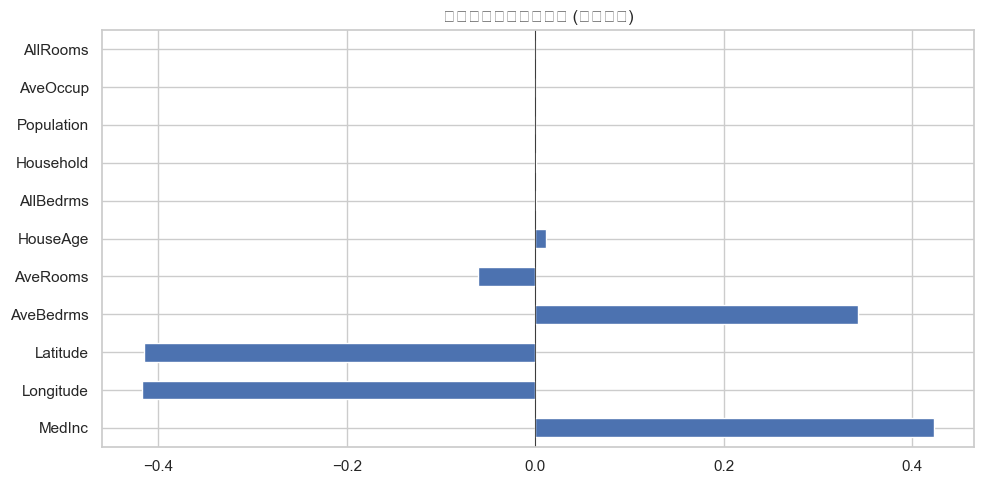

In [8]:
# 全係数を可視化
plt.figure(figsize=(10, 5))
coef_series.plot(kind='barh')
plt.title('線形回帰モデルの係数 (絶対値順)')
plt.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()


**観察**: `Latitude`, `Longitude` の係数が大きく見えますが、これは尺度の問題なので
**スケーリング後の係数で比較** するのが本来適切です。


## 4. 正則化付き線形モデル

線形回帰の係数推定が不安定になる場合に有効。

### Ridge (L2 正則化)

係数の **2 乗和** にペナルティを加える。係数全体を小さく抑える。

$$
\text{Loss} = \text{MSE} + \alpha \sum w_i^2
$$

### Lasso (L1 正則化)

係数の **絶対値の和** にペナルティを加える。不要な特徴量の係数を **0** に近づける (= 特徴量選択効果)。

$$
\text{Loss} = \text{MSE} + \alpha \sum |w_i|
$$


In [9]:
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_train, y_train)

# 係数の比較
coef_df = pd.DataFrame({
    'LinearRegression': linear.coef_,
    'Ridge': ridge.coef_,
    'Lasso': lasso.coef_,
}, index=X_train.columns)

coef_df.round(4)


,LinearRegression,Ridge,Lasso
MedInc,0.4236,0.4235,0.4211
HouseAge,0.0115,0.0115,0.0170
AveRooms,-0.0603,-0.0601,-0.0000
AveBedrms,0.3427,0.3417,0.0000
Population,-0.0004,-0.0004,-0.0004
AveOccup,-0.0002,-0.0002,-0.0000
Latitude,-0.4151,-0.4150,-0.0753
Longitude,-0.4179,-0.4178,-0.0514
Household,0.0007,0.0007,0.0013
AllRooms,-0.0000,-0.0000,-0.0001


**観察**: Lasso は係数の一部を 0 (またはほぼ 0) にしているのが分かります。
これが「特徴量選択効果」と呼ばれる挙動です。


## 5. 木系モデル

決定木は **「if-else でデータを分割していく」** モデルで、線形では表せない関係も扱えます。


In [10]:
tree = DecisionTreeRegressor(max_depth=8, random_state=0)
tree.fit(X_train, y_train)
print('決定木の深さ:', tree.get_depth())
print('葉の数:', tree.get_n_leaves())


決定木の深さ: 8
葉の数: 236


### ランダムフォレスト

決定木を **大量に作って多数決 (回帰なら平均)** する手法。
個々の木の弱点を打ち消し合うので、精度と頑健さが大きく向上します。


In [11]:
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

# 重要な特徴量
fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print('特徴量重要度:')
print(fi.head(10))


特徴量重要度:
MedInc        0.590227
AveOccup      0.136700
Latitude      0.079575
Longitude     0.074563
HouseAge      0.046397
AveRooms      0.030312
AveBedrms     0.014773
AllBedrms     0.007536
Population    0.007425
AllRooms      0.006648
dtype: float64


/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/3084869222.py:4: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/3084869222.py:4: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/3084869222.py:4: UserWarning: Glyph 24500 (\N{CJK UNIFIED IDEOGRAPH-5FB4}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/3084869222.py:4: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/3084869222.py:4: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_4303/3084

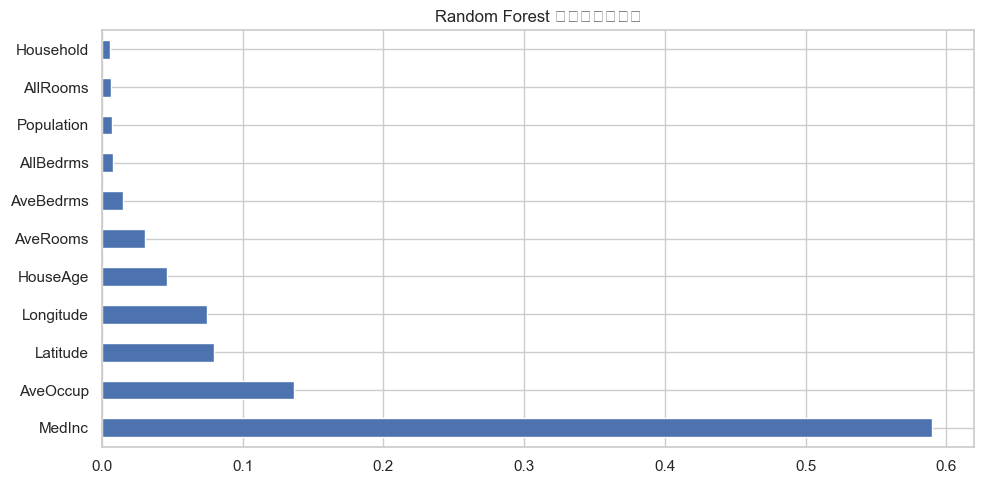

In [12]:
plt.figure(figsize=(10, 5))
fi.plot(kind='barh')
plt.title('Random Forest の特徴量重要度')
plt.tight_layout()
plt.show()


## 6. 学習結果をまとめる

各モデルの train / test スコアを並べてみます (簡易比較)。


In [13]:
from sklearn.metrics import r2_score

models = {
    'LinearRegression': linear,
    'Ridge':            ridge,
    'Lasso':            lasso,
    'DecisionTree':     tree,
    'RandomForest':     rf,
}

rows = []
for name, m in models.items():
    rows.append({
        'model': name,
        'train R²': r2_score(y_train, m.predict(X_train)),
        'test R²':  r2_score(y_test,  m.predict(X_test)),
    })
score_df = pd.DataFrame(rows)
score_df


,model,train R²,test R²
0,LinearRegression,0.640417,0.636155
1,Ridge,0.640417,0.636156
2,Lasso,0.585623,0.577339
3,DecisionTree,0.759650,0.686737
4,RandomForest,0.869723,0.778292


**観察**:
- 線形系は train/test ともに似たスコア → **適合不足 (underfit)** 気味
- DecisionTree は train で高いが test で落ちる → **過学習 (overfit)** 気味
- RandomForest は両方高い → 今回のタスクに向いている


## 7. 線形回帰モデルを採用して保存

詳細な評価は次のノートブックで行いますが、ここでは **線形回帰モデルとランダムフォレスト** を `models/` に保存しておきます。


In [14]:
# 線形回帰モデル
modeling.save_model(linear, 'linear_regression')

# ランダムフォレスト
modeling.save_model(rf, 'random_forest')

# 検証データもテスト用に保存
y_pred_linear = modeling.predict_with_clipping(linear, X_test)
data_loader.save_processed(
    X_test.assign(y_true=y_test.values, y_pred=y_pred_linear),
    'predictions_linear',
)
print('models saved.')


models saved.


## まとめ

- データは必ず **学習用と検証用に分けて** 評価する
- 信頼性のある評価には **k 分割交差検証**
- まず **シンプルな線形モデル** から試し、徐々に複雑なモデルへ
- **正則化** (Ridge / Lasso) は過学習対策に有効
- **木系モデル** (RandomForest, XGBoost) はそのままで高性能なことが多い

次は `04_evaluation.ipynb` で詳しい **評価指標とチューニング** を扱います。
